In [3]:
from script_new import test_function
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [2]:
n = 1000
m = 10
max_number_oracle_calls = n * 1000
alpha_bar_dual_sub = 1
alpha_bar_two_stage = 1

pev_problem, history_dual_sub, history_stoch_dual_sub, history_block_FW, X_sol_dual_sub, X_sol_two_stage = test_function(n, m, max_number_oracle_calls, alpha_bar_dual_sub=alpha_bar_dual_sub, alpha_bar_two_stage=alpha_bar_two_stage)



Approximate value of G = 8.787867817235574
At iteration 0, dual value = 360.2366743993
   Primal value = 360.04265711903923, infeasibility = 1.8466175636469386
At iteration 10, dual value = 361.26758254364773
   Primal value = 360.0903658342341, infeasibility = 1.800476710061752
At iteration 20, dual value = 361.8393543475979
   Primal value = 360.19879473240456, infeasibility = 1.7242534322898544
At iteration 30, dual value = 362.27351500360476
   Primal value = 360.23945556921876, infeasibility = 1.7067643143376152
At iteration 40, dual value = 362.6387343986951
   Primal value = 360.26075410278753, infeasibility = 1.7001419139917593
At iteration 50, dual value = 362.9603789722038
   Primal value = 360.2738608926768, infeasibility = 1.6969470078800886
At iteration 60, dual value = 363.25121068764275
   Primal value = 360.282739685827, infeasibility = 1.6951663238615746
At iteration 70, dual value = 363.51874021279815
   Primal value = 360.28915214754676, infeasibility = 1.69407363494

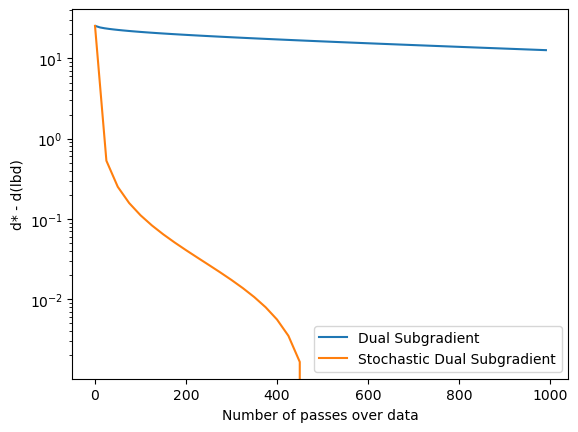

In [4]:
best_dual_value = np.maximum(np.max(history_dual_sub['dual_value']), np.max(history_stoch_dual_sub['dual_value']))

plt.plot(np.array(history_dual_sub['nb_oracle_calls'])/n, best_dual_value - np.array(history_dual_sub['dual_value']), label="Dual Subgradient")
plt.plot(np.array(history_stoch_dual_sub['nb_oracle_calls'])/n, best_dual_value - np.array(history_stoch_dual_sub['dual_value']), label="Stochastic Dual Subgradient")


plt.xlabel('Number of passes over data')
plt.ylabel('d* - d(lbd)')
plt.yscale('log')
plt.legend()

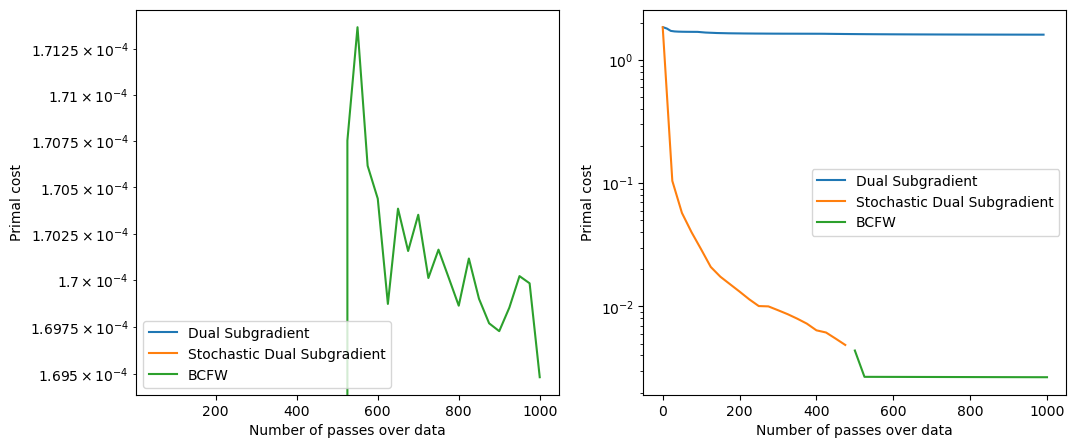

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

first_index = 5
ax1.plot(np.array(history_dual_sub['nb_oracle_calls'])[first_index:]/n, history_dual_sub['primal_value'][first_index:] - best_dual_value, label="Dual Subgradient")
ax1.plot(np.array(history_stoch_dual_sub['nb_oracle_calls'])[first_index:]/n, history_stoch_dual_sub['primal_value'][first_index:] - best_dual_value, label="Stochastic Dual Subgradient")
ax1.plot(np.array(history_block_FW['nb_oracle_calls'])/n, history_block_FW['primal_value'] - best_dual_value, label="BCFW")


ax1.set_xlabel('Number of passes over data')
ax1.set_ylabel('Primal cost')
ax1.set_yscale('log')
ax1.legend()

ax2.plot(np.array(history_dual_sub['nb_oracle_calls'])/n, history_dual_sub['infeasibility'], label="Dual Subgradient")
ax2.plot(np.array(history_stoch_dual_sub['nb_oracle_calls'])/n, history_stoch_dual_sub['infeasibility'], label="Stochastic Dual Subgradient")
ax2.plot(np.array(history_block_FW['nb_oracle_calls'])/n, history_block_FW['infeasibility'], label="BCFW")


ax2.set_xlabel('Number of passes over data')
ax2.set_ylabel('Infeasibility')
ax2.set_yscale('log')
ax2.legend()